In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load NAV Data

In [3]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


## Select a Fund

In [4]:
fund_code = nav["amfi_code"].iloc[0]

fund_nav = nav[
    nav["amfi_code"] == fund_code
].copy()

print("Selected Fund:", fund_code)
print("Records:", len(fund_nav))

Selected Fund: 119551
Records: 1150


## Calculate Daily Returns

In [5]:
fund_nav["daily_return"] = (
    fund_nav["nav"]
    .pct_change()
)

fund_nav = fund_nav.dropna()

fund_nav.head()

,amfi_code,date,nav,daily_return
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547
5,119551,2022-01-10,55.2835,-0.001548


## Calculate Historical Statistics

In [6]:
mean_return = (
    fund_nav["daily_return"]
    .mean()
)

volatility = (
    fund_nav["daily_return"]
    .std()
)

print("Mean Daily Return:", mean_return)
print("Daily Volatility:", volatility)

Mean Daily Return: 0.0009167982325947294
Daily Volatility: 0.00865628985637757


## Simulation Setup

In [7]:
num_simulations = 500
num_days = 252 * 5

last_nav = fund_nav["nav"].iloc[-1]

print("Last NAV:", last_nav)

simulations = np.zeros(
    (num_days, num_simulations)
)

Last NAV: 149.3216


## Generate 500 Future Paths

In [8]:
for i in range(num_simulations):

    prices = [last_nav]

    for _ in range(num_days):

        random_return = np.random.normal(
            mean_return,
            volatility
        )

        next_price = (
            prices[-1]
            * (1 + random_return)
        )

        prices.append(next_price)

    simulations[:, i] = prices[1:]

print(simulations.shape)

(1260, 500)


## Plot Monte Carlo Projection

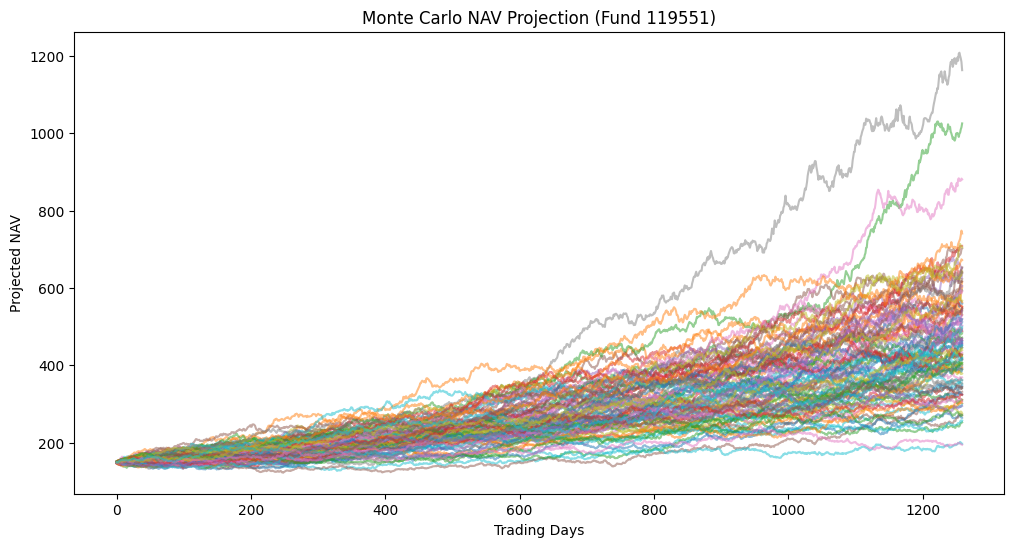

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    simulations[:, :100],
    alpha=0.5
)

plt.title(
    f"Monte Carlo NAV Projection (Fund {fund_code})"
)

plt.xlabel("Trading Days")
plt.ylabel("Projected NAV")

plt.savefig(
    "../reports/charts/monte_carlo_simulation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Summary Statistics

In [10]:
final_values = simulations[-1]

print("Minimum NAV:", final_values.min())
print("Average NAV:", final_values.mean())
print("Maximum NAV:", final_values.max())

Minimum NAV: 172.03119279135447
Average NAV: 469.7718864210788
Maximum NAV: 1239.1131648221456
